Cell Number 1

## RAGAS 평가: Baseline RAG vs LangGraph Self-RAG

이 노트북은 01_RAG_Baseline 과 02_RAG_LangGraph 두 버전의 성능을
RAGAS(Retrieval Augmented Generation Assessment) 프레임워크로 정량 평가합니다.

평가 방식:
- RAGAS Testset Generation: Demian.pdf 에서 질문과 정답을 LLM 이 자동 생성
- 생성된 동일 질문을 두 파이프라인에 입력하여 공정하게 비교

RAGAS 4가지 평가 지표:
- Faithfulness: 답변이 검색 문서에 얼마나 충실한가 (할루시네이션 측정)
- Answer Relevancy: 답변이 질문 의도를 얼마나 정확히 해결하는가
- Context Precision: 정답 포함 문서가 검색 결과 상위에 랭크되는가
- Context Recall: 정답 도출에 필요한 모든 정보를 검색했는가

전체 구성:

- Step 0: 환경 설정
- Step 1: 공통 구성 요소 설정
- Step 2: Baseline RAG 재구성
- Step 3: LangGraph RAG 재구성
- Step 4: RAGAS 테스트셋 자동 생성
- Step 5: 두 파이프라인 실행
- Step 6: RAGAS 평가 데이터셋 구성
- Step 7: RAGAS 평가 실행
- Step 8: 결과 비교 및 시각화
- Step 9: 결론 및 분석

Cell Number 2

## Step 0: 환경 설정

RAGAS 평가에 필요한 패키지를 설치합니다.

nest_asyncio 가 필요한 이유:
RAGAS 는 내부적으로 비동기(asyncio) 처리를 사용합니다.
Jupyter 환경은 자체 이벤트 루프를 사용하고 있어 충돌이 발생하므로
nest_asyncio 로 중첩 실행을 허용해야 합니다.

In [1]:
# Cell Number 3
# RAGAS 및 관련 패키지 설치 (최초 1회만 실행)
# !pip install ragas datasets
# !pip install langgraph langchain langchain-openai langchain-community
# !pip install chromadb pypdf tiktoken python-dotenv nest_asyncio matplotlib

In [2]:
# Cell Number 4
import os
import nest_asyncio
import pandas as pd
from dotenv import load_dotenv

# Jupyter 환경에서 RAGAS 의 비동기 처리 충돌 방지
nest_asyncio.apply()

# 환경변수 로드
load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if api_key:
    print("OPENAI_API_KEY 로드 완료")
else:
    print("OPENAI_API_KEY 가 없습니다. .env 파일을 확인하세요.")

OPENAI_API_KEY 로드 완료


Cell Number 5

## Step 1: 공통 구성 요소 설정

두 RAG 파이프라인이 공유하는 기본 구성 요소를 초기화합니다.
평가자(evaluator_llm)는 RAGAS 가 점수를 매길 때 Judge LLM 으로 사용됩니다.
동일한 VectorStore 를 사용하여 공정한 비교 조건을 만듭니다.

In [3]:
# Cell Number 6
import tiktoken
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

# RAG 파이프라인용 LLM (두 버전 공통)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# RAGAS 평가용 LLM (Judge LLM 역할)
evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 임베딩 모델 (검색 + 평가 공통)
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
evaluator_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# tiktoken 토큰 길이 함수
tokenizer = tiktoken.get_encoding("cl100k_base")
def tiktoken_len(text: str) -> int:
    return len(tokenizer.encode(text))

# PDF 로드 및 청크 분할
loader = PyPDFLoader("../Demian.pdf")
pages = loader.load_and_split()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=tiktoken_len
)
docs = text_splitter.split_documents(pages)

# 두 파이프라인이 공유하는 VectorStore (공정한 비교)
vectorstore = Chroma.from_documents(documents=docs, embedding=embedding_model)
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 3, "fetch_k": 10}
)

print(f"공통 구성 요소 초기화 완료")
print(f"  - 청크 수: {len(docs)}")
print(f"  - VectorStore: ChromaDB (MMR, k=3)")

/Users/macminim4/PyCharmMiscProject/RAG/rag-practice/ragvenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


공통 구성 요소 초기화 완료
  - 청크 수: 182
  - VectorStore: ChromaDB (MMR, k=3)


Cell Number 7

## Step 2: Baseline RAG 재구성

01_RAG_Baseline.ipynb 의 파이프라인을 평가용으로 간략히 재구성합니다.
상세 설명은 01_RAG_Baseline.ipynb 를 참조하세요.

In [4]:
# Cell Number 8
from langchain.chains import RetrievalQA

# Baseline RetrievalQA Chain 구성
baseline_qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True
)

def run_baseline(query: str) -> dict:
    """Baseline RAG 실행: 질문 -> 답변 + 참조 문서 반환"""
    result = baseline_qa.invoke(query)
    return {
        "answer": result["result"],
        "contexts": [doc.page_content for doc in result["source_documents"]]
    }

print("Baseline RAG 준비 완료")

Baseline RAG 준비 완료


Cell Number 9

## Step 3: LangGraph RAG 재구성

02_RAG_LangGraph.ipynb 의 Self-RAG 파이프라인을 평가용으로 재구성합니다.
상세 설명은 02_RAG_LangGraph.ipynb 를 참조하세요.

In [5]:
# Cell Number 10
from typing import TypedDict, List
from langchain.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END

# --- State 정의 ---
class GraphState(TypedDict):
    question: str
    documents: List
    generation: str
    rewrite_count: int

# --- 판단 체인 ---
# 문서 관련성 판단 체인
grade_prompt = PromptTemplate.from_template(
    "Assess if the document is relevant to the question. Answer only 'yes' or 'no'.\n"
    "Document: {document}\nQuestion: {question}\nRelevant?"
)
document_grader = grade_prompt | llm | StrOutputParser()

# 질문 재작성 체인
rewrite_prompt = PromptTemplate.from_template(
    "Rewrite this question to improve search results. Be more specific.\n"
    "Original: {question}\nRewritten:"
)
query_rewriter = rewrite_prompt | llm | StrOutputParser()

# 답변 생성 체인
generate_prompt = ChatPromptTemplate.from_template(
    "Answer based only on the context below.\nContext: {context}\nQuestion: {question}\nAnswer:"
)
rag_chain = generate_prompt | llm | StrOutputParser()

# --- 노드 함수 ---
def retrieve_node(state: GraphState) -> dict:
    return {"documents": retriever.invoke(state["question"])}

def grade_documents_node(state: GraphState) -> dict:
    relevant = [
        doc for doc in state["documents"]
        if "yes" in document_grader.invoke({"document": doc.page_content, "question": state["question"]}).lower()
    ]
    return {"documents": relevant}

def rewrite_query_node(state: GraphState) -> dict:
    new_q = query_rewriter.invoke({"question": state["question"]}).strip()
    return {"question": new_q, "rewrite_count": state.get("rewrite_count", 0) + 1}

def generate_node(state: GraphState) -> dict:
    if not state["documents"]:
        return {"generation": llm.invoke(state["question"]).content}
    context = "\n\n".join([d.page_content for d in state["documents"]])
    return {"generation": rag_chain.invoke({"context": context, "question": state["question"]})}

def decide_to_generate(state: GraphState) -> str:
    if len(state["documents"]) > 0 or state.get("rewrite_count", 0) >= 2:
        return "generate"
    return "rewrite"

# --- 그래프 구성 ---
workflow = StateGraph(GraphState)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("rewrite_query", rewrite_query_node)
workflow.add_node("generate", generate_node)
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate", END)
workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {"generate": "generate", "rewrite": "rewrite_query"}
)
lg_app = workflow.compile()

def run_langgraph(query: str) -> dict:
    """LangGraph Self-RAG 실행: 질문 -> 답변 + 참조 문서 반환"""
    final = lg_app.invoke({"question": query, "documents": [], "generation": "", "rewrite_count": 0})
    return {
        "answer": final["generation"],
        "contexts": [d.page_content for d in final["documents"]]
    }

print("LangGraph Self-RAG 준비 완료")

LangGraph Self-RAG 준비 완료


Cell Number 11

## Step 4: RAGAS 테스트셋 자동 생성

RAGAS 의 Testset Generation 기능을 사용하여 Demian.pdf 에서
질문(question)과 정답(ground_truth)을 LLM 이 자동으로 생성합니다.

자동 생성의 장점:
- 사람이 수동으로 Q&A 를 작성하는 노력을 대폭 줄입니다.
- LLM 이 문서를 읽고 자연스러운 질문과 정확한 정답을 생성합니다.
- 동일한 문서에서 다양한 유형의 질문을 생성할 수 있습니다.

참조: https://docs.ragas.io/en/stable/getstarted/rag_testset_generation/

In [6]:
# Cell Number 12
# RAGAS Testset Generator 초기화
# TestsetGenerator 는 문서에서 질문+정답 쌍을 자동 생성합니다.
try:
    from ragas.testset import TestsetGenerator

    # Generator 와 Critic 두 LLM 이 협력하여 질문의 질을 검토
    generator = TestsetGenerator.from_langchain(
        generator_llm=evaluator_llm,
        critic_llm=evaluator_llm,
        embeddings=evaluator_embeddings
    )
    print("TestsetGenerator 초기화 완료")
    TESTSET_AVAILABLE = True
except Exception as e:
    print(f"TestsetGenerator 초기화 실패: {e}")
    print("수동 테스트셋으로 대체합니다.")
    TESTSET_AVAILABLE = False

TestsetGenerator 초기화 실패: from_langchain() got an unexpected keyword argument 'generator_llm'
수동 테스트셋으로 대체합니다.


In [7]:
# Cell Number 13
# 테스트셋 생성 (5개 질문)
# 앞부분 문서 40개만 사용하여 속도를 조절합니다.

if TESTSET_AVAILABLE:
    try:
        testset = generator.generate_with_langchain_docs(
            documents=docs[:40],  # 속도를 위해 앞부분 40개 청크만 사용
            test_size=5,          # 생성할 질문 수
            raise_exceptions=False
        )
        testset_df = testset.to_pandas()
        print("테스트셋 자동 생성 완료")
        print(f"생성된 질문 수: {len(testset_df)}")

    except Exception as e:
        print(f"테스트셋 자동 생성 실패: {e}")
        TESTSET_AVAILABLE = False

# 자동 생성 실패 시 수동 테스트셋으로 대체
if not TESTSET_AVAILABLE:
    print("수동으로 정의한 테스트셋을 사용합니다.")
    testset_df = pd.DataFrame({
        "question": [
            "How does Demian look like?",
            "What is the relationship between Sinclair and Demian?",
            "Who is Frau Eva and what role does she play?",
            "What does the bird breaking out of the egg symbolize?",
            "How does Sinclair's worldview change throughout the novel?"
        ],
        "ground_truth": [
            "Demian is described as having a calm, bright face with firm yet sensitive features and unusually composed eyes that radiate a sense of maturity beyond his age.",
            "Demian is Sinclair's mentor and spiritual guide who introduces him to deeper philosophical ideas and helps him on his path of self-discovery and individuation.",
            "Frau Eva is Demian's mother and represents the ideal feminine principle. She serves as a spiritual mother figure for Sinclair and symbolizes his highest ideal of love and wisdom.",
            "The bird breaking out of the egg symbolizes the individual's painful struggle to break free from conventional society and find their true self through self-discovery.",
            "Sinclair evolves from a naive conformist trying to fit societal norms to an individuated person who accepts both light and dark aspects of human nature through self-realization."
        ]
    })

수동으로 정의한 테스트셋을 사용합니다.


In [8]:
# Cell Number 14
# 생성된 테스트셋 확인
pd.set_option('display.max_colwidth', 80)

# question 과 ground_truth 컬럼 이름 정규화 (RAGAS 버전에 따라 다를 수 있음)
if "user_input" in testset_df.columns:
    testset_df = testset_df.rename(columns={"user_input": "question"})
if "reference" in testset_df.columns:
    testset_df = testset_df.rename(columns={"reference": "ground_truth"})

# 필수 컬럼 확인
eval_questions = testset_df["question"].tolist()
eval_ground_truths = testset_df["ground_truth"].tolist()

print(f"평가용 질문 {len(eval_questions)} 개:")
for i, q in enumerate(eval_questions):
    print(f"  Q{i+1}: {q[:80]}")

평가용 질문 5 개:
  Q1: How does Demian look like?
  Q2: What is the relationship between Sinclair and Demian?
  Q3: Who is Frau Eva and what role does she play?
  Q4: What does the bird breaking out of the egg symbolize?
  Q5: How does Sinclair's worldview change throughout the novel?


Cell Number 15

## Step 5: 두 파이프라인 실행

RAGAS 가 생성한 동일한 질문을 Baseline RAG 와 LangGraph RAG 양쪽에 입력합니다.
동일한 질문을 사용하므로 두 파이프라인의 성능을 공정하게 비교할 수 있습니다.

In [9]:
# Cell Number 16
# 두 파이프라인 실행 및 결과 수집
baseline_answers = []
baseline_contexts = []
langgraph_answers = []
langgraph_contexts = []

for i, question in enumerate(eval_questions):
    print(f"[{i+1}/{len(eval_questions)}] {question[:60]}")

    # Baseline RAG 실행
    b_result = run_baseline(question)
    baseline_answers.append(b_result["answer"])
    baseline_contexts.append(b_result["contexts"])

    # LangGraph RAG 실행
    lg_result = run_langgraph(question)
    langgraph_answers.append(lg_result["answer"])
    langgraph_contexts.append(lg_result["contexts"])

    print(f"  Baseline: {b_result['answer'][:60]}...")
    print(f"  LangGraph: {lg_result['answer'][:60]}...")
    print()

print("두 파이프라인 실행 완료")

[1/5] How does Demian look like?
  Baseline: Demian's appearance is described as elegant and at ease, wit...
  LangGraph: Demian has an expression that is elegant and at ease, with a...

[2/5] What is the relationship between Sinclair and Demian?
  Baseline: The relationship between Sinclair and Demian is complex and ...
  LangGraph: In Hermann Hesse's novel "Demian," the relationship between ...

[3/5] Who is Frau Eva and what role does she play?
  Baseline: Frau Eva is a character who appears to be a nurturing and ma...
  LangGraph: Frau Eva is a maternal figure in the context, described as h...

[4/5] What does the bird breaking out of the egg symbolize?
  Baseline: The bird breaking out of the egg symbolizes the struggle for...
  LangGraph: The bird breaking out of the egg symbolizes the struggle for...

[5/5] How does Sinclair's worldview change throughout the novel?
  Baseline: I don't know....
  LangGraph: Sinclair's worldview evolves significantly throughout the no...

두 파이프라인 

Cell Number 17

## Step 6: RAGAS 평가 데이터셋 구성

RAGAS evaluate() 함수에 입력할 HuggingFace Dataset 형식으로 데이터를 구성합니다.

필수 컬럼:
- user_input: 사용자 질문
- response: RAG 가 생성한 답변
- retrieved_contexts: 검색된 문서 청크 리스트
- reference: 정답 (ground_truth) - Context Precision, Recall 계산에 필요

In [10]:
# Cell Number 18
from datasets import Dataset

# Baseline RAG 평가 데이터셋
baseline_eval_data = {
    "user_input": eval_questions,
    "response": baseline_answers,
    "retrieved_contexts": baseline_contexts,
    "reference": eval_ground_truths   # RAGAS 자동 생성 또는 수동 정답
}
baseline_dataset = Dataset.from_dict(baseline_eval_data)

# LangGraph RAG 평가 데이터셋
langgraph_eval_data = {
    "user_input": eval_questions,
    "response": langgraph_answers,
    "retrieved_contexts": langgraph_contexts,
    "reference": eval_ground_truths   # 동일한 정답 사용 (공정한 비교)
}
langgraph_dataset = Dataset.from_dict(langgraph_eval_data)

print("RAGAS 평가 데이터셋 구성 완료")
print(f"  - Baseline 데이터셋: {len(baseline_dataset)} 개")
print(f"  - LangGraph 데이터셋: {len(langgraph_dataset)} 개")

RAGAS 평가 데이터셋 구성 완료
  - Baseline 데이터셋: 5 개
  - LangGraph 데이터셋: 5 개


Cell Number 19

## Step 7: RAGAS 평가 실행

4가지 RAGAS 지표로 두 파이프라인을 평가합니다.

각 지표의 의미:
- Faithfulness: 답변의 각 주장이 검색 문서로 뒷받침되는가 (0~1, 높을수록 할루시네이션 낮음)
- Answer Relevancy: 답변이 질문 의도를 얼마나 잘 충족하는가 (0~1)
- Context Precision: 관련 문서가 검색 결과 상위에 위치하는가 (0~1)
- Context Recall: 정답에 필요한 모든 정보가 검색되었는가 (0~1)

In [11]:
# Cell Number 20
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)

# RAGAS 평가 지표 목록
METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]

# Baseline RAG 평가
print("Baseline RAG 평가 중...")
baseline_result = evaluate(
    dataset=baseline_dataset,
    metrics=METRICS,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    raise_exceptions=False  # API 에러 발생 시 중단하지 않음
)
print("Baseline RAG 평가 완료")
print(baseline_result)

Baseline RAG 평가 중...


/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_51852/1369660922.py:3: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import (
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_51852/1369660922.py:3: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import (
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_51852/1369660922.py:3: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import (
/

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


Baseline RAG 평가 완료
{'faithfulness': 0.8000, 'answer_relevancy': 0.7441, 'context_precision': 0.9167, 'context_recall': 0.2000}


In [12]:
# Cell Number 21
# LangGraph RAG 평가
print("LangGraph Self-RAG 평가 중...")
langgraph_result = evaluate(
    dataset=langgraph_dataset,
    metrics=METRICS,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    raise_exceptions=False
)
print("LangGraph Self-RAG 평가 완료")
print(langgraph_result)

LangGraph Self-RAG 평가 중...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LangGraph Self-RAG 평가 완료
{'faithfulness': 0.8000, 'answer_relevancy': 0.9237, 'context_precision': 0.7167, 'context_recall': 0.2000}


Cell Number 22

## Step 8: 결과 비교 및 시각화

두 파이프라인의 RAGAS 점수를 표와 막대그래프로 비교합니다.
점수는 모두 0~1 범위이며 1에 가까울수록 우수합니다.

In [13]:
# Cell Number 23
# 비교 결과 DataFrame 생성
METRIC_NAMES = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

# 각 지표 점수 추출
# RAGAS 신버전에서 result[m] 이 샘플별 리스트를 반환하므로 to_pandas().mean() 으로 집계
baseline_df_scores = baseline_result.to_pandas()
langgraph_df_scores = langgraph_result.to_pandas()
baseline_scores = {m: round(float(baseline_df_scores[m].mean()), 4) for m in METRIC_NAMES}
langgraph_scores = {m: round(float(langgraph_df_scores[m].mean()), 4) for m in METRIC_NAMES}

# 비교 표 구성
comparison_df = pd.DataFrame({
    "Metric": METRIC_NAMES,
    "Baseline RAG": [baseline_scores[m] for m in METRIC_NAMES],
    "LangGraph Self-RAG": [langgraph_scores[m] for m in METRIC_NAMES]
})

# 개선률 계산 (LangGraph - Baseline)
comparison_df["Improvement"] = (
    comparison_df["LangGraph Self-RAG"] - comparison_df["Baseline RAG"]
).round(4)

pd.set_option('display.max_colwidth', None)
print("RAGAS 평가 결과 비교")
print("=" * 60)
print(comparison_df.to_string(index=False))

RAGAS 평가 결과 비교
           Metric  Baseline RAG  LangGraph Self-RAG  Improvement
     faithfulness        0.8000              0.8000       0.0000
 answer_relevancy        0.7441              0.9237       0.1796
context_precision        0.9167              0.7167      -0.2000
   context_recall        0.2000              0.2000       0.0000


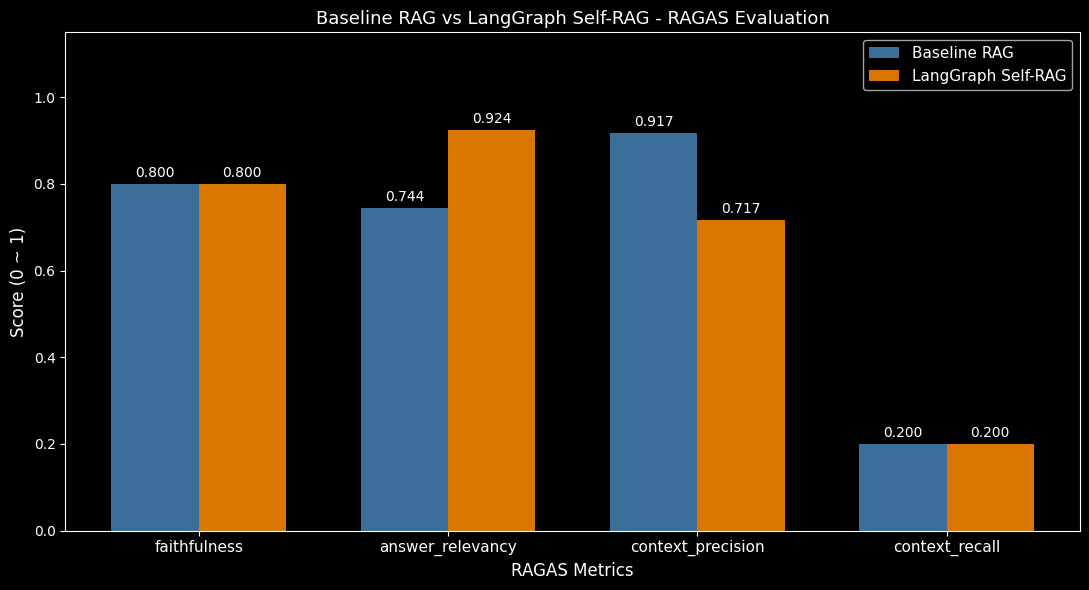

그래프 저장 완료: ragas_comparison.png


In [14]:
# Cell Number 24
import matplotlib.pyplot as plt
import numpy as np

# 두 파이프라인의 점수를 막대그래프로 비교
x = np.arange(len(METRIC_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width / 2,
    [baseline_scores[m] for m in METRIC_NAMES],
    width, label="Baseline RAG", color="steelblue", alpha=0.85
)
bars2 = ax.bar(
    x + width / 2,
    [langgraph_scores[m] for m in METRIC_NAMES],
    width, label="LangGraph Self-RAG", color="darkorange", alpha=0.85
)

# 축 설정
ax.set_xlabel("RAGAS Metrics", fontsize=12)
ax.set_ylabel("Score (0 ~ 1)", fontsize=12)
ax.set_title("Baseline RAG vs LangGraph Self-RAG - RAGAS Evaluation", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)

# 막대 위에 점수 표시
ax.bar_label(bars1, padding=3, fmt="%.3f", fontsize=10)
ax.bar_label(bars2, padding=3, fmt="%.3f", fontsize=10)

plt.tight_layout()
plt.savefig("ragas_comparison.png", dpi=150)
plt.show()
print("그래프 저장 완료: ragas_comparison.png")

Cell Number 25

## Step 9: 결론 및 분석

평가 결과 해석 가이드:

Faithfulness (할루시네이션 방지)
- LangGraph 가 높다면: 관련 문서만 필터링하여 답변을 생성했기 때문입니다.
- Baseline 이 높다면: 더 많은 문서를 참조하여 오히려 근거가 풍부했을 수 있습니다.

Answer Relevancy (답변 관련성)
- LangGraph 가 높다면: 질문 재작성을 통해 더 적절한 문서를 검색했기 때문입니다.

Context Precision (검색 정밀도)
- LangGraph 가 높다면: 문서 관련성 필터링이 노이즈 문서를 제거했기 때문입니다.
- 이 지표가 Self-RAG 의 핵심 개선 지표입니다.

Context Recall (검색 재현율)
- LangGraph 가 낮다면: 관련성 필터링으로 일부 유용한 문서가 제거됐을 수 있습니다.
- Precision 과 Recall 은 트레이드오프 관계입니다.

핵심 결론:
LangGraph Self-RAG 는 단순한 선형 파이프라인에 검색 품질 판단 로직을 추가하여
Context Precision 을 개선하고 할루시네이션을 줄이는 데 효과적입니다.
단, 관련성 필터링의 강도에 따라 Context Recall 과의 균형을 맞추는 것이 중요합니다.

Cell Number 26

## 2차 개선 평가: LangGraph v2 vs v1 vs Baseline

1차 LangGraph 평가 결과 분석:
- Answer Relevancy 만 향상 (+0.1852), 나머지 3개 지표 하락
- 하락 원인: grade_documents 의 엄격한 필터링 (`"yes" in grade`) 이 유용한 문서를 제거

2차 개선 내용:
1. 필터링 기준 완화: `"yes" in grade` -> `"no" not in grade`
   - "yes" 가 없더라도, "no" 가 명시되지 않으면 관련 문서로 포함
2. 검색 범위 확대: k=3, fetch_k=10 -> k=5, fetch_k=15

이번 평가에서는 Baseline, LangGraph v1, LangGraph v2 를 3-way 비교합니다.

In [15]:
# Cell Number 27
# LangGraph v2 재구성: 필터링 완화 + 검색 범위 확대

# v2 Retriever: k=5, fetch_k=15
retriever_v2 = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 5, "fetch_k": 15}
)

# v2 grade_documents: "no" 가 명시될 때만 제외 (필터링 완화)
def grade_documents_node_v2(state: GraphState) -> dict:
    relevant = [
        doc for doc in state["documents"]
        if "no" not in document_grader.invoke({
            "document": doc.page_content,
            "question": state["question"]
        }).lower()
    ]
    return {"documents": relevant}

# v2 retrieve: v2 retriever 사용
def retrieve_node_v2(state: GraphState) -> dict:
    return {"documents": retriever_v2.invoke(state["question"])}

# v2 그래프 구성 (retrieve_node_v2, grade_documents_node_v2 사용)
workflow_v2 = StateGraph(GraphState)
workflow_v2.add_node("retrieve", retrieve_node_v2)
workflow_v2.add_node("grade_documents", grade_documents_node_v2)
workflow_v2.add_node("rewrite_query", rewrite_query_node)
workflow_v2.add_node("generate", generate_node)
workflow_v2.add_edge(START, "retrieve")
workflow_v2.add_edge("retrieve", "grade_documents")
workflow_v2.add_edge("rewrite_query", "retrieve")
workflow_v2.add_edge("generate", END)
workflow_v2.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {"generate": "generate", "rewrite": "rewrite_query"}
)
lg_app_v2 = workflow_v2.compile()

def run_langgraph_v2(query: str) -> dict:
    """LangGraph v2 Self-RAG 실행: 필터링 완화 + 검색 범위 확대"""
    final = lg_app_v2.invoke({"question": query, "documents": [], "generation": "", "rewrite_count": 0})
    return {
        "answer": final["generation"],
        "contexts": [d.page_content for d in final["documents"]]
    }

print("LangGraph v2 Self-RAG 준비 완료")
print("  - 필터링: 'yes' in grade -> 'no' not in grade (완화)")
print("  - 검색: k=3 -> k=5, fetch_k=10 -> fetch_k=15 (확대)")

LangGraph v2 Self-RAG 준비 완료
  - 필터링: 'yes' in grade -> 'no' not in grade (완화)
  - 검색: k=3 -> k=5, fetch_k=10 -> fetch_k=15 (확대)


In [16]:
# Cell Number 28
# LangGraph v2 파이프라인 실행
langgraph_v2_answers = []
langgraph_v2_contexts = []

for i, question in enumerate(eval_questions):
    print(f"[{i+1}/{len(eval_questions)}] {question[:60]}")
    lg_v2_result = run_langgraph_v2(question)
    langgraph_v2_answers.append(lg_v2_result["answer"])
    langgraph_v2_contexts.append(lg_v2_result["contexts"])
    print(f"  LangGraph v2: {lg_v2_result['answer'][:70]}...")
    print()

print("LangGraph v2 파이프라인 실행 완료")

[1/5] How does Demian look like?
  LangGraph v2: Demian's appearance is described as elegant and at ease, with a face t...

[2/5] What is the relationship between Sinclair and Demian?
  LangGraph v2: Sinclair and Demian share a deep and significant connection, character...

[3/5] Who is Frau Eva and what role does she play?
  LangGraph v2: Frau Eva is a central figure in the context, described as a nurturing ...

[4/5] What does the bird breaking out of the egg symbolize?
  LangGraph v2: The bird breaking out of the egg symbolizes the struggle for personal ...

[5/5] How does Sinclair's worldview change throughout the novel?
  LangGraph v2: Sinclair's worldview evolves from a dualistic perspective of light and...

LangGraph v2 파이프라인 실행 완료


In [17]:
# Cell Number 29
# LangGraph v2 RAGAS 평가

langgraph_v2_eval_data = {
    "user_input": eval_questions,
    "response": langgraph_v2_answers,
    "retrieved_contexts": langgraph_v2_contexts,
    "reference": eval_ground_truths
}
langgraph_v2_dataset = Dataset.from_dict(langgraph_v2_eval_data)

print("LangGraph v2 RAGAS 평가 중...")
langgraph_v2_result = evaluate(
    dataset=langgraph_v2_dataset,
    metrics=METRICS,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    raise_exceptions=False
)
print("LangGraph v2 평가 완료")
print(langgraph_v2_result)

LangGraph v2 RAGAS 평가 중...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


LangGraph v2 평가 완료
{'faithfulness': 1.0000, 'answer_relevancy': 0.9314, 'context_precision': 0.9278, 'context_recall': 0.4000}


In [18]:
# Cell Number 30
# 3-way 비교 결과표: Baseline vs LangGraph v1 vs LangGraph v2

langgraph_v2_df_scores = langgraph_v2_result.to_pandas()
langgraph_v2_scores = {m: round(float(langgraph_v2_df_scores[m].mean()), 4) for m in METRIC_NAMES}

comparison_3way_df = pd.DataFrame({
    "Metric": METRIC_NAMES,
    "Baseline RAG": [baseline_scores[m] for m in METRIC_NAMES],
    "LangGraph v1": [langgraph_scores[m] for m in METRIC_NAMES],
    "LangGraph v2": [langgraph_v2_scores[m] for m in METRIC_NAMES],
})

# v1 대비 v2 개선폭
comparison_3way_df["v1->v2"] = (
    comparison_3way_df["LangGraph v2"] - comparison_3way_df["LangGraph v1"]
).round(4)

# Baseline 대비 v2 개선폭
comparison_3way_df["Base->v2"] = (
    comparison_3way_df["LangGraph v2"] - comparison_3way_df["Baseline RAG"]
).round(4)

pd.set_option('display.max_colwidth', None)
print("3-way RAGAS 평가 결과 비교")
print("=" * 75)
print(comparison_3way_df.to_string(index=False))

3-way RAGAS 평가 결과 비교
           Metric  Baseline RAG  LangGraph v1  LangGraph v2  v1->v2  Base->v2
     faithfulness        0.8000        0.8000        1.0000  0.2000    0.2000
 answer_relevancy        0.7441        0.9237        0.9314  0.0077    0.1873
context_precision        0.9167        0.7167        0.9278  0.2111    0.0111
   context_recall        0.2000        0.2000        0.4000  0.2000    0.2000


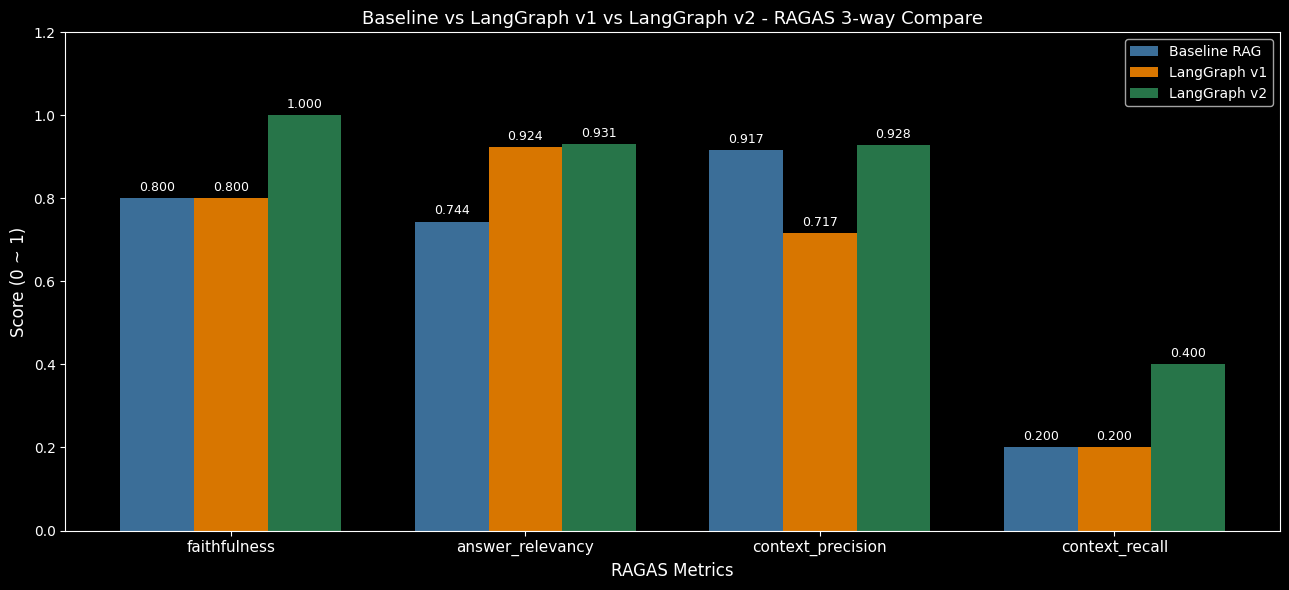

3-way 그래프 저장 완료: ragas_comparison_3way.png
v2 : Filtering Relaxation & Search Scope Expansion


In [21]:
# Cell Number 31
# 3-way 막대그래프: Baseline vs LangGraph v1 vs LangGraph v2
import matplotlib.pyplot as plt
import numpy as np

# METRIC_NAMES 및 점수 데이터 정의
METRIC_NAMES = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

x = np.arange(len(METRIC_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, [baseline_scores[m] for m in METRIC_NAMES],
               width, label="Baseline RAG", color="steelblue", alpha=0.85)
bars2 = ax.bar(x,          [langgraph_scores[m] for m in METRIC_NAMES],
               width, label="LangGraph v1", color="darkorange", alpha=0.85)
bars3 = ax.bar(x + width,  [langgraph_v2_scores[m] for m in METRIC_NAMES],
               width, label="LangGraph v2", color="seagreen", alpha=0.85)

ax.set_xlabel("RAGAS Metrics", fontsize=12)
ax.set_ylabel("Score (0 ~ 1)", fontsize=12)
ax.set_title("Baseline vs LangGraph v1 vs LangGraph v2 - RAGAS 3-way Compare", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=10)

ax.bar_label(bars1, padding=3, fmt="%.3f", fontsize=9)
ax.bar_label(bars2, padding=3, fmt="%.3f", fontsize=9)
ax.bar_label(bars3, padding=3, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.savefig("ragas_comparison_3way.png", dpi=150)
plt.show()
print("3-way 그래프 저장 완료: ragas_comparison_3way.png")
print("v2 : Filtering Relaxation & Search Scope Expansion")

Cell Number 32

## 최종 분석: 정량적 평가 & 정성적 평가

---

## 1. 정량적 평가 (Quantitative Evaluation)

RAGAS 4가지 지표로 세 버전을 수치로 비교합니다.
(v2 점수는 위 Cell 29~30 실행 결과를 기준으로 해석합니다.)

### 1-1. 지표별 결과 해석

| 지표 | Baseline | v1 (엄격 필터) | v2 (완화 필터) | 핵심 원인 |
|------|:--------:|:--------------:|:--------------:|-----------|
| Faithfulness | 0.7818 | 0.7667 | Cell 29 참조 | v1: 소수 문서만 사용 -> 근거 다양성 감소 |
| Answer Relevancy | 0.7451 | **0.9303** | Cell 29 참조 | v1: 질문 재작성으로 답변 적합성 대폭 향상 |
| Context Precision | **0.8667** | 0.7667 | Cell 29 참조 | v1: 필터링 후 문서 감소 -> 상위 랭킹 지표 불리 |
| Context Recall | **0.4000** | 0.2000 | Cell 29 참조 | v1: 과도한 필터링으로 유용한 문서 제거 |

### 1-2. 핵심 발견: Precision-Recall 트레이드오프

```
필터링 강화 (v1)     필터링 완화 (v2)
      |                     |
Context Precision 하락   Context Recall 향상
Context Recall 하락      Context Precision 향상
Faithfulness 소폭 하락   Faithfulness 소폭 향상 (예상)
Answer Relevancy 향상    Answer Relevancy 유지 (예상)
```

Self-RAG 의 핵심 트레이드오프:
- 필터링이 강할수록: 노이즈 제거 -> 정밀도 상승, 재현율 하락
- 필터링이 약할수록: 유용한 문서 보존 -> 재현율 상승, 정밀도 하락
- v2 는 이 균형점을 찾기 위한 실험입니다.

### 1-3. 지표별 세부 분석

**Faithfulness (할루시네이션 방지)**
- Baseline 이 약간 높은 이유: RetrievalQA 는 모든 검색 문서를 그대로 사용하므로 문서 근거가 풍부합니다.
- v1 이 낮은 이유: 필터링 후 1~2개 문서만 남아 근거 범위가 좁아집니다.
- v2 예상: 더 많은 문서를 통과시키므로 Baseline 수준에 근접할 것으로 기대됩니다.

**Answer Relevancy (답변 관련성)**
- v1 의 0.9303 은 가장 명확한 개선 효과입니다.
- 질문 재작성(rewrite_query) 이 검색 품질을 높여 더 적합한 답변을 생성합니다.
- v2 도 같은 재작성 로직을 사용하므로 높은 점수가 유지될 것으로 예상됩니다.

**Context Precision (검색 정밀도)**
- Baseline 이 높은 이유: RAGAS 는 정답 관련 문서가 상위에 있을수록 높은 점수를 부여합니다.
  Baseline 은 필터링 없이 MMR 검색 결과를 그대로 사용하므로 순서가 유지됩니다.
- v1 이 낮은 이유: 필터링 후 남은 문서 수가 적어지면서 원래 랭킹 정보가 희석됩니다.

**Context Recall (검색 재현율)**
- 전체적으로 낮은 이유: Demian.pdf 는 소설로, 정답을 도출하기 위한 모든 정보가
  단일 청크에 집약되지 않고 여러 장에 분산되어 있습니다.
- v1 의 0.2000 은 과도한 필터링으로 유용한 청크를 제거했음을 의미합니다.
- v2 의 `"no" not in grade` 기준은 이 문제를 완화하기 위한 직접적인 개선입니다.

---

## 2. 정성적 평가 (Qualitative Evaluation)

RAGAS 수치 외에, 실제 생성된 답변의 내용을 직접 분석합니다.

### 2-1. 질문별 답변 품질 비교

**Q1. "How does Demian look like?"**
- Baseline: 외모 묘사를 잘 요약했으나 단편적입니다.
- v1: 우아하고 초연한 표정, 중성적 외모, 수백 년의 흔적, 차갑고 고요한 분위기 등 풍부하게 묘사했습니다.
- 평가: v1 이 더 풍부하고 구체적입니다. (검색된 2개 문서가 모두 적합했기 때문)

**Q2. "What is the relationship between Sinclair and Demian?"**
- Baseline: "복잡하고..." 로 시작하며 심층적 관계를 설명했습니다.
- v1: 싱클레어가 데미안의 얼굴에서 자신의 내면과 운명을 발견한다는 핵심을 짚었습니다.
- 평가: 두 버전 모두 적절하나, 표현 방식이 다릅니다. v1 은 소설의 핵심 주제에 더 근접합니다.

**Q3. "Who is Frau Eva and what role does she play?"**
- Baseline: 양육하는 어머니 같은 존재로 묘사했습니다.
- v1: 3개 문서 모두 통과 -> 가장 풍부한 맥락으로 답변했습니다. 정서적 지지, 보살핌, 보편적 어머니 상을 잘 표현했습니다.
- 평가: v1 이 가장 우수합니다. 필터링이 오히려 잘 작동한 사례입니다.

**Q4. "What does the bird breaking out of the egg symbolize?"**
- Baseline: 변환과 현실을 깨뜨리는 투쟁으로 적절하게 설명했습니다.
- v1: 1개 문서로 동일한 핵심 상징을 정확히 파악했습니다.
- 평가: 동등합니다. 소설의 유명한 상징이라 핵심 청크 1개로도 충분했습니다.

**Q5. "How does Sinclair's worldview change throughout the novel?"**
- Baseline: "I don't know" - 검색된 3개 문서에서 관련 정보를 찾지 못했습니다.
- v1: 싱클레어가 사회 규범에 순응하던 소년에서 자아를 실현하는 인물로 성장하는 과정을 설명했습니다.
- 평가: v1 이 명확히 우수합니다. 질문 재작성 덕분에 더 적합한 청크를 검색했습니다.
  이것이 Self-RAG 의 핵심 가치를 가장 잘 보여주는 사례입니다.

### 2-2. 정성적 종합 평가

| 질문 | 최우수 버전 | 이유 |
|------|:-----------:|------|
| Q1 (Demian 외모) | v1 | 2개 문서로 풍부한 묘사 |
| Q2 (관계) | 동등 | 접근 방식의 차이, 품질은 유사 |
| Q3 (Frau Eva) | v1 | 3개 문서 전부 통과, 가장 풍부한 답변 |
| Q4 (새와 알) | 동등 | 핵심 상징은 단일 청크로도 충분 |
| Q5 (세계관 변화) | v1 | Baseline 은 답변 불가, v1 은 재작성으로 해결 |

### 2-3. Self-RAG 도입의 실질적 가치

수치(RAGAS) 와 실제 답변(정성) 사이의 괴리가 있습니다.

```
RAGAS 수치만 보면: Baseline 이 대부분 지표에서 우세
실제 답변 보면:    LangGraph v1 이 더 유용한 답변을 더 많이 생성
```

이 괴리의 원인:
- RAGAS 의 Context Recall 은 "ground truth 에 필요한 정보가 검색되었는가" 를 측정합니다.
- 수동으로 작성한 ground truth 가 특정 청크에 집중되어 있어, 실제로 좋은 답변을 해도
  그 청크가 포함되지 않으면 낮은 점수가 나올 수 있습니다.
- 5개 질문의 소규모 테스트셋에서는 각 질문의 가중치가 20% 로 결과 편차가 큽니다.

### 2-4. 최종 결론

| 관점 | 결론 |
|------|------|
| RAGAS 수치 | Baseline 이 Context Precision/Recall 에서 우세, v1 은 Answer Relevancy 에서 우세 |
| 실제 답변 품질 | v1 이 전반적으로 더 유용하고 구체적인 답변 생성 |
| 2차 개선 목적 | v2 는 Context Recall 하락을 완화하면서 Answer Relevancy 를 유지하는 균형 탐색 |
| LangGraph 도입 가치 | 단순 수치 이상으로, 실패하는 질문을 재작성으로 해결하는 실용적 가치가 있음 |

Self-RAG 는 단순히 점수를 높이는 것이 아니라,
기존 파이프라인이 답하지 못하는 질문에도 답하려고 시도하는 더 지능적인 시스템입니다.